# Sampling constrained shares

> A short, standalone illustration (not part of the numbered series).

Many MFA parameters are **shares** of a flow: the fraction recycled vs
landfilled, or the split between drive technologies (the BEV share in
Notebook 6). Shares are constrained — each part must lie in **[0, 1]** and the
parts must **sum to 1** — and any sampling scheme has to respect that.

This notebook shows three approaches of increasing generality:

1. **Normal + clip** for two parts — sample one part, take the other as `1 − x`.
2. **Beta** — a distribution that lives on [0, 1] directly, no clipping.
3. **Dirichlet** — the multi-part generalisation, samples living on the simplex.

There are no gaps to fill in — it just runs. Two of the plots have **interactive
sliders** (via `ipywidgets`); those need a running kernel (JupyterLab), so in a
statically-rendered copy you will see the reference plot but not the sliders.

In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, FloatLogSlider

rng = np.random.default_rng(20260703)

# Running example: the share of an end-of-life flow that is *recycled*.
m_rec = 0.80     # best estimate: 80% recycled
sd_rec = 0.15    # uncertainty (standard deviation)
N = 20_000       # Monte Carlo samples

## 1. Normal about the estimate, clipped to [0, 1], complement takes the rest

This is exactly what Notebook 6 did for the BEV share. Sample the recycled
share from a normal centred on the estimate, clip it into [0, 1], and let the
other part be whatever is left over:

    x = clip( Normal(mean, sd), 0, 1 )        # recycled
    other = 1 − x                             # not recycled

By construction the two parts are in [0, 1] and sum to 1.

In [2]:
x = np.clip(rng.normal(m_rec, sd_rec, N), 0, 1)     # recycled share
shares_1 = np.column_stack([x, 1 - x])              # [recycled, not recycled]

assert np.all((shares_1 >= 0) & (shares_1 <= 1))
assert np.allclose(shares_1.sum(axis=1), 1.0)

print(f"target mean            {m_rec:.3f}")
print(f"realised mean (clipped) {x.mean():.3f}")
print(f"fraction stuck at 1.0   {np.mean(x == 1.0):.1%}")

target mean            0.800
realised mean (clipped) 0.794
fraction stuck at 1.0   9.4%


Two problems show up when the estimate is near a boundary (as 0.80 is):

- **Clipping piles probability mass on the boundary** — a spike of samples at
  exactly 1.0, which is not a realistic description of the uncertainty.
- **Clipping biases the mean** away from the target (here it drops below 0.80),
  and the closer the estimate sits to 0 or 1, the worse this gets.

The normal is also symmetric, which is a poor fit near a boundary where the real
distribution must be squashed on one side. And there is no clean way to extend
`1 − x` to more than two parts. The next two approaches fix these.

## 2. Beta distribution — [0, 1] directly, no clipping

The **Beta** distribution lives on [0, 1] by construction, so no clipping is
needed, and it can be skewed to sit naturally against a boundary. Its complement
`1 − x` is also Beta, so the two parts still sum to 1.

It is convenient to parameterise it by the **mean** and a **concentration** `κ`
(think of `κ` as a pseudo-sample-size — larger `κ` means a tighter distribution):

    α = mean · κ,   β = (1 − mean) · κ,   with   κ = mean·(1−mean)/sd² − 1

so we can ask for the same mean and (approximately) the same spread as above.

*Other options exist* — e.g. a **logit-normal**: sample a normal on the
log-odds `log(x/(1−x))` and map back with the inverse logit. That also stays in
(0, 1) and can be handy when you want to reason on the log-odds scale.

In [3]:
def beta_from_mean_sd(mean, sd):
    """Beta (alpha, beta) with the given mean and standard deviation."""
    kappa = mean * (1 - mean) / sd**2 - 1        # concentration (pseudo-count)
    return mean * kappa, (1 - mean) * kappa

a, b = beta_from_mean_sd(m_rec, sd_rec)
xb = rng.beta(a, b, N)                            # recycled share
shares_2 = np.column_stack([xb, 1 - xb])

assert np.all((shares_2 >= 0) & (shares_2 <= 1))
assert np.allclose(shares_2.sum(axis=1), 1.0)

print(f"Beta(alpha={a:.2f}, beta={b:.2f})")
print(f"mean {xb.mean():.3f}  (target {m_rec}),  sd {xb.std():.3f}  (target {sd_rec})")

Beta(alpha=4.89, beta=1.22)
mean 0.800  (target 0.8),  sd 0.150  (target 0.15)


Overlay the two recycled-share distributions. Same mean and spread, but the
clipped normal spikes at the boundary while the Beta approaches it smoothly. The
function below draws the comparison for any mean/spread; we call it once at the
best estimate for a static reference:

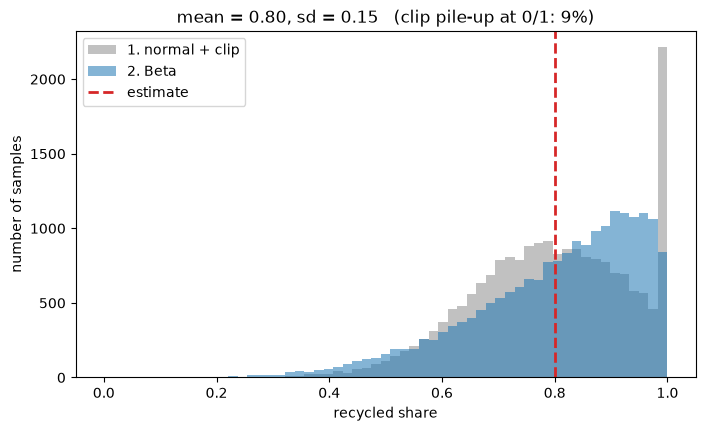

In [4]:
def plot_beta_vs_clip(mean=m_rec, sd=sd_rec):
    """Compare a clipped-normal share with a Beta of the same mean and spread."""
    g = np.random.default_rng(0)                 # fixed seed: only the params change
    sd_beta = min(sd, 0.99 * np.sqrt(mean * (1 - mean)))   # keep Beta's kappa > 0
    xc = np.clip(g.normal(mean, sd, N), 0, 1)              # 1. normal + clip
    xbeta = g.beta(*beta_from_mean_sd(mean, sd_beta), N)   # 2. Beta

    bins = np.linspace(0, 1, 60)
    plt.figure(figsize=(8, 4.5))
    plt.hist(xc, bins=bins, color="0.6", alpha=0.6, label="1. normal + clip")
    plt.hist(xbeta, bins=bins, color="C0", alpha=0.55, label="2. Beta")
    plt.axvline(mean, color="C3", lw=2, ls="--", label="estimate")
    plt.xlabel("recycled share"); plt.ylabel("number of samples")
    plt.title(f"mean = {mean:.2f}, sd = {sd:.2f}   "
              f"(clip pile-up at 0/1: {np.mean((xc == 0) | (xc == 1)):.0%})")
    plt.legend(); plt.show()


plot_beta_vs_clip()

**Interactive** (JupyterLab): drag the estimate towards a boundary and widen the
spread to watch the clipped-normal grow a spike while the Beta stays smooth.

In [ ]:
interact(
    plot_beta_vs_clip,
    mean=FloatSlider(min=0.05, max=0.95, step=0.05, value=m_rec, description="mean"),
    sd=FloatSlider(min=0.02, max=0.20, step=0.01, value=sd_rec, description="sd"),
);

## 3. Dirichlet — the generalisation to many parts

For **K parts** that must all be non-negative and sum to 1 (a point on the
*simplex*), the **Dirichlet** distribution is the natural generalisation of the
Beta — in fact the Beta is just the Dirichlet with K = 2. Each sample is a whole
share-vector that satisfies the constraint automatically.

We parameterise it by a **mean share vector** and a **concentration** `κ`:

    alpha = κ · mean_shares

Here the flow splits three ways — recycling, landfill, incineration:

In [5]:
parts = ["recycling", "landfill", "incineration"]
mean_shares = np.array([0.5, 0.3, 0.2])
kappa = 20                                        # larger = tighter around the mean
alpha = kappa * mean_shares

S = rng.dirichlet(alpha, size=N)                  # shape (N, 3), each row sums to 1

assert np.all(S >= 0)
assert np.allclose(S.sum(axis=1), 1.0)

for i, name in enumerate(parts):
    print(f"{name:13s} target {mean_shares[i]:.2f}   "
          f"sampled mean {S[:, i].mean():.3f}   sd {S[:, i].std():.3f}")

recycling     target 0.50   sampled mean 0.501   sd 0.108
landfill      target 0.30   sampled mean 0.299   sd 0.100
incineration  target 0.20   sampled mean 0.200   sd 0.087


Each marginal is itself a Beta, and the components are automatically **negatively
correlated** — if one share is large the others must be smaller (the dependence
theme of Notebook 8, here built in for free). We can see the whole cloud by
plotting it on the simplex (the triangle whose corners are the three pure
states). Again the plot is wrapped in a function and called once for a static
reference:

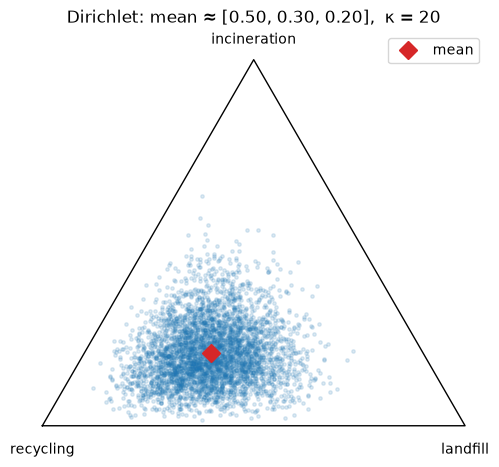

In [6]:
def ternary_xy(p):
    """Map share-vectors (rows summing to 1) to 2-D triangle coordinates."""
    return p[:, 1] + 0.5 * p[:, 2], (np.sqrt(3) / 2) * p[:, 2]


def plot_dirichlet(recycling=0.5, landfill=0.3, kappa=20.0):
    """Scatter Dirichlet samples on the simplex for the given mean shares and κ."""
    g = np.random.default_rng(0)
    m = np.array([recycling, landfill, max(1 - recycling - landfill, 0.0)])
    m = m / m.sum()                               # normalise to a valid share vector
    Sd = g.dirichlet(kappa * m, size=4000)

    xs, ys = ternary_xy(Sd)
    mx, my = ternary_xy(m[None, :])
    corners = np.array([[0, 0], [1, 0], [0.5, np.sqrt(3) / 2], [0, 0]])

    plt.figure(figsize=(6, 5.5))
    plt.plot(corners[:, 0], corners[:, 1], "k-", lw=1)
    plt.scatter(xs, ys, s=6, alpha=0.15, color="C0")
    plt.plot(mx, my, "D", color="C3", ms=9, label="mean")
    plt.text(0, -0.04, parts[0], ha="center", va="top")
    plt.text(1, -0.04, parts[1], ha="center", va="top")
    plt.text(0.5, np.sqrt(3) / 2 + 0.03, parts[2], ha="center", va="bottom")
    plt.axis("equal"); plt.axis("off")
    plt.title(f"Dirichlet: mean ≈ [{m[0]:.2f}, {m[1]:.2f}, {m[2]:.2f}],  κ = {kappa:.0f}")
    plt.legend(); plt.show()


plot_dirichlet()

**Interactive** (JupyterLab): move the mean around the triangle and change `κ` to
tighten or loosen the cloud (incineration takes whatever recycling and landfill
leave over).

In [ ]:
interact(
    plot_dirichlet,
    recycling=FloatSlider(min=0.05, max=0.90, step=0.05, value=0.5, description="recycling"),
    landfill=FloatSlider(min=0.05, max=0.90, step=0.05, value=0.3, description="landfill"),
    kappa=FloatLogSlider(base=10, min=np.log10(2), max=np.log10(500), value=20, description="κ"),
);

## Takeaways

- **Normal + clip** (approach 1) is the quickest fix for two parts, and fine when
  the estimate sits well inside [0, 1] with a modest spread. But near a boundary
  it piles samples onto the boundary and biases the mean, and it does not extend
  cleanly beyond two parts.
- **Beta** (approach 2) lives on [0, 1] by construction — no clipping, no spike,
  and it can be skewed to sit naturally against a boundary. A mean + concentration
  parameterisation makes it easy to specify.
- **Dirichlet** (approach 3) generalises this to any number of parts on the
  simplex, guaranteeing non-negativity and sum-to-1, with the components sensibly
  (negatively) correlated. The Beta is the two-part special case.